In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.append(str(REPO_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import Counter, defaultdict

from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
from causallearn.utils.cit import chisq

DATA_DIR    = REPO_ROOT / "data"
FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

In [2]:
# Load the PC-learned graph + binarized matrix from Day 3
graph_data = torch.load(DATA_DIR / "pc_learned_graph.pt", weights_only=False)
edges_orig    = graph_data["edges"]
col_to_layer  = graph_data["col_to_layer"]
col_to_feat   = graph_data["col_to_feat"]
LAYERS        = graph_data["layers"]
X_binary      = graph_data["X_binary"]    # [N, 115] used to train PC originally
n_features = len(col_to_layer)
N = X_binary.shape[0]

# Load the case study so we can track its persistence
case = torch.load(DATA_DIR / "case_study_and_validation.pt", weights_only=False)
A_case = case["case_study"]["A"]["col"]
B_case = case["case_study"]["B"]["col"]
C_case = case["case_study"]["C"]["col"]
print(f"Loaded:")
print(f"  X_binary shape: {X_binary.shape}")
print(f"  Original edges: {len(edges_orig)}")
print(f"  Case study v-structure: cols ({A_case}, {C_case}, {B_case})")
print(f"    A: L{col_to_layer[A_case]} F{col_to_feat[A_case]}")
print(f"    B: L{col_to_layer[B_case]} F{col_to_feat[B_case]}")
print(f"    C: L{col_to_layer[C_case]} F{col_to_feat[C_case]}")


Loaded:
  X_binary shape: (5000, 115)
  Original edges: 366
  Case study v-structure: cols (13, 60, 27)
    A: L18 F15143
    B: L18 F2297
    C: L22 F10566


In [3]:
# Helper: extract edges and v-structures from a causal-learn CausalGraph output
def extract_edges_and_vstructs(G_matrix, col_to_layer):
    """
    Convert a causal-learn output to:
      - edges: set of (parent_col, child_col) — directed by layer prior for cross-layer,
               by PC's orientation otherwise; undirected stored as frozenset
      - vstructs: list of (A, C, B) tuples where A → C ← B and A,B not adjacent
    """
    n = G_matrix.shape[0]
    directed_edges = set()
    undirected_edges = set()
    adjacency = {i: set() for i in range(n)}
    parents = {i: set() for i in range(n)}

    for i in range(n):
        for j in range(i + 1, n):
            edge_present = (G_matrix[i, j] != 0) or (G_matrix[j, i] != 0)
            if not edge_present:
                continue
            adjacency[i].add(j)
            adjacency[j].add(i)
            L_i = col_to_layer[i] if col_to_layer else None
            L_j = col_to_layer[j] if col_to_layer else None

            # Cross-layer: orient by layer prior
            if col_to_layer and L_i != L_j:
                if L_i < L_j:
                    directed_edges.add((i, j))
                    parents[j].add(i)
                else:
                    directed_edges.add((j, i))
                    parents[i].add(j)
            else:
                # Use PC's own orientation if available
                if G_matrix[i, j] == -1 and G_matrix[j, i] == 1:
                    directed_edges.add((i, j))
                    parents[j].add(i)
                elif G_matrix[i, j] == 1 and G_matrix[j, i] == -1:
                    directed_edges.add((j, i))
                    parents[i].add(j)
                else:
                    undirected_edges.add(frozenset([i, j]))

    # Find v-structures from parent sets
    vstructs = []
    for c in range(n):
        plist = sorted(parents[c])
        for i, A in enumerate(plist):
            for B in plist[i+1:]:
                if B not in adjacency[A]:
                    vstructs.append((A, c, B))

    return directed_edges, undirected_edges, vstructs

# Reconstruct the original (Day 3) edge set in the same format
edges_orig_set = set()
for p, c, _ in edges_orig:
    edges_orig_set.add((p, c))

print(f"Reconstructed {len(edges_orig_set)} edges from Day 3 graph for comparison.")


Reconstructed 366 edges from Day 3 graph for comparison.


In [4]:
import numpy as np

print(f"X_binary type: {type(X_binary)}")
print(f"X_binary dtype: {X_binary.dtype}")
print(f"X_binary shape: {X_binary.shape}")
if hasattr(X_binary, 'device'):
    print(f"X_binary device: {X_binary.device}")
print(f"X_binary[0, :5]: {X_binary[0, :5]}")

# Try a tiny PC run to see if it works at all
print("\nTrying tiny PC test (5 features, 100 samples)...")
import time
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import chisq

X_small = X_binary[:100, :5]
print(f"X_small type: {type(X_small)}, dtype: {X_small.dtype}")

t0 = time.time()
try:
    cg_test = pc(data=X_small, alpha=0.05, indep_test=chisq, show_progress=False)
    print(f"PC tiny run completed in {time.time() - t0:.2f}s")
except Exception as e:
    print(f"PC failed: {type(e).__name__}: {e}")

X_binary type: <class 'numpy.ndarray'>
X_binary dtype: int8
X_binary shape: (5000, 115)
X_binary device: cpu
X_binary[0, :5]: [0 1 0 1 1]

Trying tiny PC test (5 features, 100 samples)...
X_small type: <class 'numpy.ndarray'>, dtype: int8
PC tiny run completed in 0.01s


In [5]:
from tqdm import tqdm

# Run from stricter to looser alpha. Later values can be much slower.
ALPHAS = [0.001, 0.005, 0.01, 0.05, 0.1]
alpha_results = []

# stable=True is the standard PC variant (more conservative, often slower).
# Set to False for faster exploratory runs.
PC_STABLE = True

print(f"Running PC at {len(ALPHAS)} alpha values sequentially...")
print("(α=0.001 is usually fastest; α=0.05 and 0.1 may take much longer)")
print(f"PC stable mode: {PC_STABLE}")
print()

for alpha in tqdm(ALPHAS, desc="Alpha sweep"):
    print(f"Starting alpha={alpha:.3f}...", flush=True)
    t0 = time.time()
    cg = pc(
        data=X_binary,
        alpha=alpha,
        indep_test=chisq,
        stable=PC_STABLE,
        show_progress=True,
    )
    elapsed = time.time() - t0

    G = cg.G.graph
    directed, undirected, vstructs = extract_edges_and_vstructs(G, col_to_layer)
    total_edges = len(directed) + len(undirected)
    cross_layer_edges = sum(1 for p, c in directed
                            if col_to_layer[p] != col_to_layer[c])

    case_present = any(
        (A == A_case and C == C_case and B == B_case) or
        (A == B_case and C == C_case and B == A_case)
        for A, C, B in vstructs
    )

    alpha_results.append({
        "alpha":             alpha,
        "total_edges":       total_edges,
        "cross_layer_edges": cross_layer_edges,
        "n_vstructs":        len(vstructs),
        "case_present":      case_present,
        "runtime_s":         elapsed,
        "stable":            PC_STABLE,
    })
    tqdm.write(f"  α={alpha:.3f}: {total_edges:>4d} edges ({cross_layer_edges} cross-layer), "
               f"{len(vstructs):>4d} v-structs, "
               f"case={'✓' if case_present else '✗'}, "
               f"{elapsed:.1f}s")

Running PC at 5 alpha values sequentially...
(α=0.001 is usually fastest; α=0.05 and 0.1 may take much longer)
PC stable mode: True



Alpha sweep:   0%|          | 0/5 [00:00<?, ?it/s]

Starting alpha=0.001...


  0%|          | 0/115 [00:00<?, ?it/s]

Alpha sweep:  20%|██        | 1/5 [09:07<36:28, 547.13s/it]

...

Alpha sweep:  80%|████████  | 4/5 [1:07:45<20:09, 1209.66s/it]

  α=0.050:  418 edges (273 cross-layer),  779 v-structs, case=✓, 1883.0s
Starting alpha=0.100...


  0%|          | 0/115 [00:00<?, ?it/s]

Alpha sweep: 100%|██████████| 5/5 [1:57:03<00:00, 1404.78s/it]

  α=0.100:  442 edges (292 cross-layer),  844 v-structs, case=✓, 2958.9s


=== Alpha Sweep Summary ===
   alpha   edges   cross-layer   v-structs   case?
   0.001     324           211         434    True
   0.005     359           232         567    True
   0.010     366           237         591    True
   0.050     418           273         779    True
   0.100     442           292         844    True


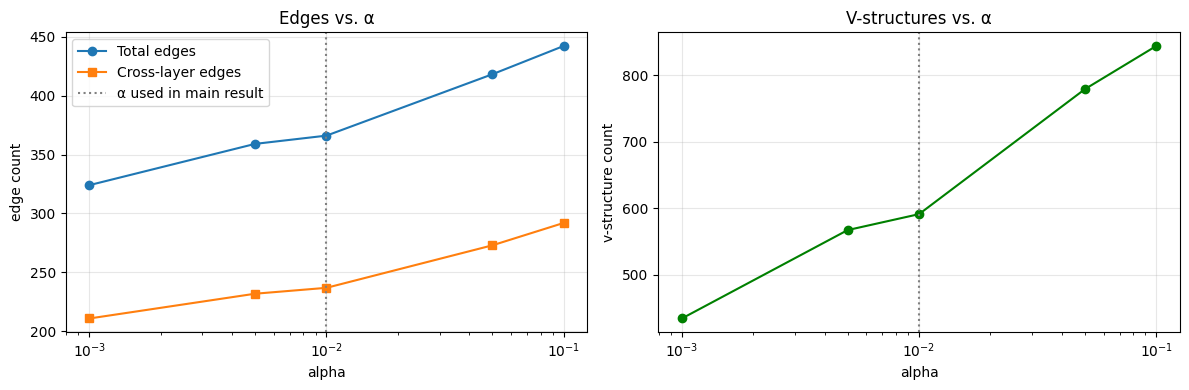

In [6]:
# Summary table
print("=== Alpha Sweep Summary ===")
print(f"{'alpha':>8s}  {'edges':>6s}  {'cross-layer':>12s}  {'v-structs':>10s}  {'case?':>6s}")
for r in alpha_results:
    print(f"{r['alpha']:>8.3f}  {r['total_edges']:>6d}  {r['cross_layer_edges']:>12d}  "
          f"{r['n_vstructs']:>10d}  {str(r['case_present']):>6s}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
alphas_arr   = [r["alpha"] for r in alpha_results]
edges_arr    = [r["total_edges"] for r in alpha_results]
vstructs_arr = [r["n_vstructs"] for r in alpha_results]

axes[0].semilogx(alphas_arr, edges_arr, "o-", label="Total edges")
axes[0].semilogx(alphas_arr, [r["cross_layer_edges"] for r in alpha_results],
                 "s-", label="Cross-layer edges")
axes[0].axvline(0.01, color="grey", linestyle=":", label="α used in main result")
axes[0].set_xlabel("alpha"); axes[0].set_ylabel("edge count"); axes[0].legend()
axes[0].set_title("Edges vs. α")
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(alphas_arr, vstructs_arr, "o-", color="green")
axes[1].axvline(0.01, color="grey", linestyle=":")
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("v-structure count")
axes[1].set_title("V-structures vs. α")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "alpha_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
